# Paper Figures (Public Data)

---

Reproduces the main-text figures of the manuscript that rely on the public ADME dataset (Figures 1, 2, 4, and 5).

Prerequisites:
- Run `../../scripts/run_unique.py` to generate `../../unique_output/{model_id}/uq_metrics_values.csv`.
- Run `./Building_Error_Models.ipynb` to generate `inputdata_benchmarking_data.csv` and `inputfeatures_benchmarking_data.csv` under `../../unique_output/{model_id}/error_models/`.

In [29]:
import pandas as pd
import numpy as np
from scipy import stats

import itertools
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="ticks")

import warnings
warnings.filterwarnings('ignore')

seed = 42

In [30]:
# Define the endpoints dictionary: {endpoint_group: {model_name: model_id}}
endpoints_dict = {'clint': {'rLM LogCLint': 'clint_rat', 'hLM LogCLint': 'clint_human'},
                  'ppb':   {'LogFu-Rat': 'ppb_rat', 'LogFu-Human': 'ppb_human'},
                  'mdr1':  {'MDCK-MDR1_LogER': 'mdck_mdr1_er'}}

# Endpoints and display names used across the figures
endpoints = ['rLM LogCLint', 'hLM LogCLint', 'LogFu-Rat', 'LogFu-Human', 'MDCK-MDR1_LogER']
endpoint_names = ['rLM LogCLint', 'hLM LogCLint', 'Rat Logfu', 'Human Logfu', 'MDR1 LogER']

## Figure 1

Distribution of the absolute true error per endpoint and data subset (Training / Calibration / Test), plus a mean-of-training baseline evaluated on Test.

In [31]:
error_df = pd.DataFrame(columns=['Endpoint', 'True Error', 'which_set'])

for endpoint, models_dict in endpoints_dict.items():
    print(f'\n### {endpoint} ###\n')

    for model_name, model_id in models_dict.items():
        print(f'\n### {model_name} ###\n')

        # Load UNIQUE input data
        data = pd.read_csv(f'unique_input_data/{model_name}_unique_input_data.csv')
        # Calculate the true absolute error
        data['True Error'] = np.abs(data['labels'] - data['predictions'])
        data['Endpoint'] = model_name

        # Baseline: mean of training labels as constant predictor
        baseline_df = data.loc[data.which_set == 'TEST'].copy()
        baseline_df['which_set'] = 'Baseline (TEST)'
        train_mean = np.mean(data.labels.loc[data.which_set == 'TRAIN'])
        baseline_df['True Error'] = np.abs(baseline_df['labels'] - train_mean)

        error_df = pd.concat([error_df,
                              data[['Endpoint', 'True Error', 'which_set']],
                              baseline_df[['Endpoint', 'True Error', 'which_set']]], ignore_index=True)


### clint ###


### rLM LogCLint ###


### hLM LogCLint ###


### ppb ###


### LogFu-Rat ###


### LogFu-Human ###


### mdr1 ###


### MDCK-MDR1_LogER ###



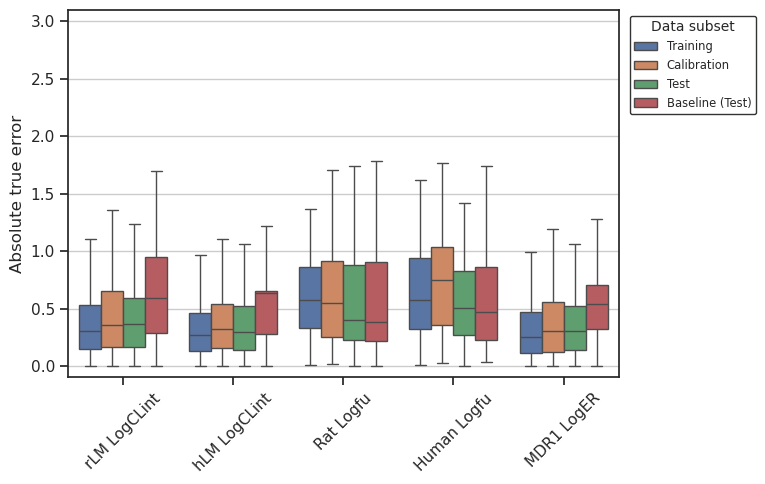

In [32]:
plt.figure(figsize=(8, 5))

ax = sns.boxplot(data=error_df, x='Endpoint', order=endpoints, y='True Error',
                 hue='which_set', hue_order=['TRAIN', 'CALIBRATION', 'TEST', 'Baseline (TEST)'],
                 linewidth=1, fliersize=3, showfliers=False)

ax.set_xticklabels(endpoint_names, rotation=45)

handles, _ = ax.get_legend_handles_labels()
plt.legend(handles, ['Training', 'Calibration', 'Test', 'Baseline (Test)'],
           loc='upper right', bbox_to_anchor=(1.26, 1),
           fontsize='x-small', title='Data subset', title_fontsize='small',
           frameon=True, fancybox=True, facecolor='white', edgecolor='black')

plt.xlabel('')
plt.ylabel('Absolute true error')
plt.grid(axis='y')
plt.ylim(-0.1, 3.1)
plt.tight_layout()
plt.show()

## Figure 2

Compare the effect of the **input features** used to train the UNIQUE error model:
- `Data features` — 300 scaled latent fingerprint features only.
- `Distance + Variance + Prediction` — the three UQ-derived summary features.
- `All` — data features + UQ metrics + prediction.

For each endpoint, the SRCC between predicted uncertainty and true absolute error on the Test set is estimated by 100 bootstrap replicates. Pairwise Wilcoxon signed-rank tests with Benjamini–Hochberg correction identify the best-performing error model (marked with `*`).

In [33]:
error_models_list = ['UniqueRandomForestRegressor[latent_fp_scaled](l1)',
                     'UniqueRandomForestRegressor[UQmetrics+predictions](l1)',
                     'UniqueRandomForestRegressor[latent_fp_scaled+UQmetrics+predictions](l1)']

In [34]:
bs_results = {}
best_methods = {}

for endpoint, models_dict in endpoints_dict.items():
    print(f'\n### {endpoint} ###\n')

    for model_name, model_id in models_dict.items():
        print(f'\n### {model_name} ###\n')
        bs_results[model_name] = {}
        best_methods[model_name] = {}

        # Load UNIQUE input data
        input_data = pd.read_csv(f'unique_input_data/{model_name}_unique_input_data.csv', index_col=0).reset_index(drop=True)
        print(input_data.shape)
        # Load UNIQUE-computed uncertainty values
        uq_metrics_data = pd.read_csv(f'unique_output/{model_id}/{model_id}_uq_metrics_values.csv')
        print(uq_metrics_data.shape)
        # Load uncertainty values for the EM trained only on data (latent fp) features
        only_data_features_em = pd.read_csv(
            f'unique_output/{model_id}/error_models/latent_fp_scaled_UQmetrics_predictions/inputfeatures_benchmarking_data.csv',
            index_col=0).reset_index(drop=True)
        only_data_features_em = only_data_features_em.rename(
            columns={'em_predictions_onlydatafeatures': 'UniqueRandomForestRegressor[latent_fp_scaled](l1)'})
        print(only_data_features_em.shape)

        # Aggregate all uncertainty sources
        bs_df = pd.concat([input_data[['Id', 'labels', 'predictions', 'which_set']],
                          uq_metrics_data[['UniqueRandomForestRegressor[UQmetrics+predictions](l1)',
                                           'UniqueRandomForestRegressor[latent_fp_scaled+UQmetrics+predictions](l1)']],
                          only_data_features_em[['UniqueRandomForestRegressor[latent_fp_scaled](l1)']]], axis=1)
        print(bs_df.shape)

        # Select TEST data
        bs_df_test = bs_df.loc[bs_df.which_set == 'TEST'].reset_index(drop=True)
        print(bs_df_test.shape)

        # Bootstrap resampling
        replicas_dict = {"uq_values": [], "predictions": [], "labels": []}
        n_bootstrap = 100
        np.random.seed(seed)

        for _ in range(n_bootstrap):
            sample_indices = np.random.choice(len(bs_df_test), size=len(bs_df_test))
            replicas_dict["uq_values"].append(bs_df_test.iloc[sample_indices][error_models_list])
            replicas_dict["predictions"].append(bs_df_test.predictions[sample_indices])
            replicas_dict["labels"].append(bs_df_test.labels[sample_indices])

        # Spearman correlation per method per bootstrap replicate
        for uq_method in error_models_list:
            spearman_values = []
            for n in range(n_bootstrap):
                uq_values = replicas_dict["uq_values"][n][uq_method]
                spearman = stats.spearmanr(np.abs(replicas_dict["predictions"][n] - replicas_dict["labels"][n]),
                                           uq_values)[0]
                spearman_values.append(spearman)
            bs_results[model_name][uq_method] = spearman_values

        # Pairwise Wilcoxon signed-rank tests + BH correction
        comparisons = list(itertools.combinations(error_models_list, 2))
        wilcoxon_results = []
        for method1, method2 in comparisons:
            data1 = np.array(bs_results[model_name][method1])
            data2 = np.array(bs_results[model_name][method2])
            differences = data1 - data2
            if np.all(differences == 0):
                p_value = 1.0
            else:
                _, p_value = wilcoxon(differences)
            mean_diff = np.mean(data1) - np.mean(data2)
            wilcoxon_results.append((method1, method2, mean_diff, p_value))

        wilcoxon_df = pd.DataFrame(wilcoxon_results, columns=["group1", "group2", "meandiff", "p"])
        reject, p_values_corrected, _, _ = multipletests(wilcoxon_df["p"].values, alpha=0.05, method="fdr_bh")
        wilcoxon_df["p_adj"] = p_values_corrected
        wilcoxon_df["reject"] = reject

        # Score each method by pairwise wins
        method_scores = {method: 0 for method in error_models_list}
        for _, row in wilcoxon_df.iterrows():
            method1, method2, mean_diff, p_value, p_adj, reject = row
            if reject:
                if mean_diff > 0:
                    method_scores[method1] += 1
                elif mean_diff < 0:
                    method_scores[method2] += 1

        best_method = [method for method, score in method_scores.items() if score == max(method_scores.values())]

        # Also mark methods statistically indistinguishable from the best
        wilcoxon_filtered = wilcoxon_df.loc[(wilcoxon_df['group1'].eq(best_method[0]) | wilcoxon_df['group2'].eq(best_method[0])), :]
        is_best_different = []
        for _, row in wilcoxon_filtered.iterrows():
            method1, method2, _, _, _, reject = row
            is_best_different.append({'method': method1 if best_method[0] != method1 else method2,
                                      'is_best_significant': reject})
        is_best_different_df = pd.DataFrame(is_best_different)

        best_methods[model_name] = [best_method[0]] + is_best_different_df['method'].loc[is_best_different_df.is_best_significant == False].tolist()


### clint ###


### rLM LogCLint ###

(3051, 7)
(3051, 9)
(3051, 307)
(3051, 7)
(609, 7)

### hLM LogCLint ###

(3084, 7)
(3084, 9)
(3084, 307)
(3084, 7)
(616, 7)

### ppb ###


### LogFu-Rat ###

(167, 7)
(167, 9)
(167, 307)
(167, 7)
(32, 7)

### LogFu-Human ###

(193, 7)
(193, 9)
(193, 307)
(193, 7)
(39, 7)

### mdr1 ###


### MDCK-MDR1_LogER ###

(2639, 7)
(2639, 9)
(2639, 307)
(2639, 7)
(527, 7)


In [36]:
# Build the long-form DataFrame for the boxplot
boxplots_df = pd.DataFrame()
for endpoint, inner_dict in bs_results.items():
    for uq_method, spearman_values in inner_dict.items():
        tmp_df = pd.DataFrame({'endpoint': endpoint, 'uq_method': uq_method, 'eval_metric': spearman_values})
        boxplots_df = pd.concat([boxplots_df, tmp_df], ignore_index=True)

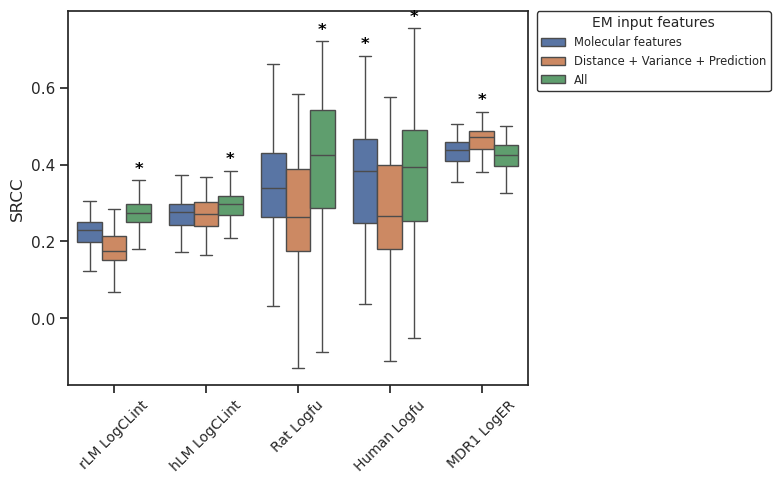

In [38]:
# Display names for each error model
error_models_display_names = {'UniqueRandomForestRegressor[UQmetrics+predictions](l1)': 'Distance + Variance + Prediction',
                              'UniqueRandomForestRegressor[latent_fp_scaled+UQmetrics+predictions](l1)': 'All',
                              'UniqueRandomForestRegressor[latent_fp_scaled](l1)': 'Molecular features'}

plt.figure(figsize=(8, 5))
ax = sns.boxplot(data=boxplots_df, x="endpoint", y="eval_metric", hue="uq_method",
                 order=endpoints, hue_order=error_models_list, linewidth=1, fliersize=3, showfliers=False)

plt.ylabel('SRCC')
plt.xlabel('')
plt.xticks(ticks=ax.get_xticks(), labels=endpoint_names, fontsize=10, rotation=45)

# add '*' label to the best method for each endpoint
boxplot_width = 0.8
n_methods = len(error_models_list)
each_width = boxplot_width / n_methods
for endpoint in endpoints:
    for best_method in best_methods[endpoint]:
        # Get endpoint and method indexes and compute the x-coordinate
        endpoint_index = endpoints.index(endpoint)
        method_index = error_models_list.index(best_method)
        x_coord = endpoint_index + (method_index - (n_methods - 1) / 2) * each_width
        # Compute the y-coordinate
        values = boxplots_df['eval_metric'].loc[(boxplots_df.endpoint == endpoint) & (boxplots_df.uq_method == best_method)].values
        q1, q3 = np.percentile(values, [25, 75])
        iqr = q3 - q1
        upper_whisker = values[values <= q3 + 1.5 * iqr].max()
        y_coord = upper_whisker + 0.01
        # Add the '*' text label at the computed coordinates
        ax.text(x=x_coord, y=y_coord, s='*', ha='center', va='bottom', fontsize=12, color='black', weight='semibold')

handles, labels = ax.get_legend_handles_labels()
new_labels = [error_models_display_names[label] for label in labels]
# Anchor the legend's upper-left corner just outside the axes' right edge,
# so its position doesn't depend on the legend's width
plt.legend(handles, new_labels, loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0,
           fontsize='x-small', title='EM input features', title_fontsize='small',
           frameon=True, fancybox=True, facecolor='white', edgecolor='black')


plt.tight_layout()
plt.show()

## Figure 4

Compare the effect of the **ML algorithm** used for the UNIQUE error model (Lasso vs. Random Forest) on Test-set SRCC. Both columns are read from `mlalgorithm_benchmarking_data.csv` (produced by `./Building_Error_Models.ipynb`), where the RF predictions are taken directly from the UNIQUE output and the Lasso predictions come from a `LassoCV`-fitted model trained on the same features (`Manhattan Distance`, `Ensemble Variance`, `Predictions`).

In [51]:
error_models_list = ['UniqueLASSO[UQmetrics+predictions](l1)', 'UniqueRandomForestRegressor[UQmetrics+predictions](l1)']

In [52]:
bs_results = {}
best_methods = {}

for endpoint, models_dict in endpoints_dict.items():
    print(f'\n### {endpoint} ###\n')

    for model_name, model_id in models_dict.items():
        print(f'\n### {model_name} ###\n')
        bs_results[model_name] = {}
        best_methods[model_name] = {}

        # Load UNIQUE input data
        input_data = pd.read_csv(f'unique_input_data/{model_name}_unique_input_data.csv', index_col=0).reset_index(drop=True)
        print(input_data.shape)
        # Load UQ metrics values
        uq_metrics_data = pd.read_csv(f'unique_output/{model_id}/{model_id}_uq_metrics_values.csv')
        print(uq_metrics_data.shape)

        # Aggregate
        bs_df = pd.concat([input_data[['Id', 'labels', 'predictions', 'which_set']],
                           uq_metrics_data[error_models_list]], axis=1)
        print(bs_df.shape)

        bs_df_test = bs_df.loc[bs_df.which_set == 'TEST'].reset_index(drop=True)
        print(bs_df_test.shape)

        # Bootstrap resampling
        replicas_dict = {"uq_values": [], "predictions": [], "labels": []}
        n_bootstrap = 100
        np.random.seed(seed)
        for _ in range(n_bootstrap):
            sample_indices = np.random.choice(len(bs_df_test), size=len(bs_df_test))
            replicas_dict["uq_values"].append(bs_df_test.iloc[sample_indices][error_models_list])
            replicas_dict["predictions"].append(bs_df_test.predictions[sample_indices])
            replicas_dict["labels"].append(bs_df_test.labels[sample_indices])

        for uq_method in error_models_list:
            spearman_values = []
            for n in range(n_bootstrap):
                uq_values = replicas_dict["uq_values"][n][uq_method]
                spearman = stats.spearmanr(np.abs(replicas_dict["predictions"][n] - replicas_dict["labels"][n]),
                                           uq_values)[0]
                spearman_values.append(spearman)
            bs_results[model_name][uq_method] = spearman_values

        # Pairwise Wilcoxon + BH correction
        comparisons = list(itertools.combinations(error_models_list, 2))
        wilcoxon_results = []
        for method1, method2 in comparisons:
            data1 = np.array(bs_results[model_name][method1])
            data2 = np.array(bs_results[model_name][method2])
            differences = data1 - data2
            if np.all(differences == 0):
                p_value = 1.0
            else:
                _, p_value = wilcoxon(differences)
            mean_diff = np.mean(data1) - np.mean(data2)
            wilcoxon_results.append((method1, method2, mean_diff, p_value))

        wilcoxon_df = pd.DataFrame(wilcoxon_results, columns=["group1", "group2", "meandiff", "p"])
        reject, p_values_corrected, _, _ = multipletests(wilcoxon_df["p"].values, alpha=0.05, method="fdr_bh")
        wilcoxon_df["p_adj"] = p_values_corrected
        wilcoxon_df["reject"] = reject

        method_scores = {method: 0 for method in error_models_list}
        for _, row in wilcoxon_df.iterrows():
            method1, method2, mean_diff, p_value, p_adj, reject = row
            if reject:
                if mean_diff > 0:
                    method_scores[method1] += 1
                elif mean_diff < 0:
                    method_scores[method2] += 1

        best_method = [method for method, score in method_scores.items() if score == max(method_scores.values())]

        wilcoxon_filtered = wilcoxon_df.loc[(wilcoxon_df['group1'].eq(best_method[0]) | wilcoxon_df['group2'].eq(best_method[0])), :]
        is_best_different = []
        for _, row in wilcoxon_filtered.iterrows():
            method1, method2, _, _, _, reject = row
            is_best_different.append({'method': method1 if best_method[0] != method1 else method2,
                                      'is_best_significant': reject})
        is_best_different_df = pd.DataFrame(is_best_different)

        best_methods[model_name] = [best_method[0]] + is_best_different_df['method'].loc[is_best_different_df.is_best_significant == False].tolist()


### clint ###


### rLM LogCLint ###

(3051, 7)
(3051, 12)
(3051, 6)
(609, 6)

### hLM LogCLint ###

(3084, 7)
(3084, 12)
(3084, 6)
(616, 6)

### ppb ###


### LogFu-Rat ###

(167, 7)
(167, 12)
(167, 6)
(32, 6)

### LogFu-Human ###

(193, 7)
(193, 12)
(193, 6)
(39, 6)

### mdr1 ###


### MDCK-MDR1_LogER ###

(2639, 7)
(2639, 12)
(2639, 6)
(527, 6)


In [54]:
boxplots_df = pd.DataFrame()
for endpoint, inner_dict in bs_results.items():
    for uq_method, spearman_values in inner_dict.items():
        tmp_df = pd.DataFrame({'endpoint': endpoint, 'uq_method': uq_method, 'eval_metric': spearman_values})
        boxplots_df = pd.concat([boxplots_df, tmp_df], ignore_index=True)

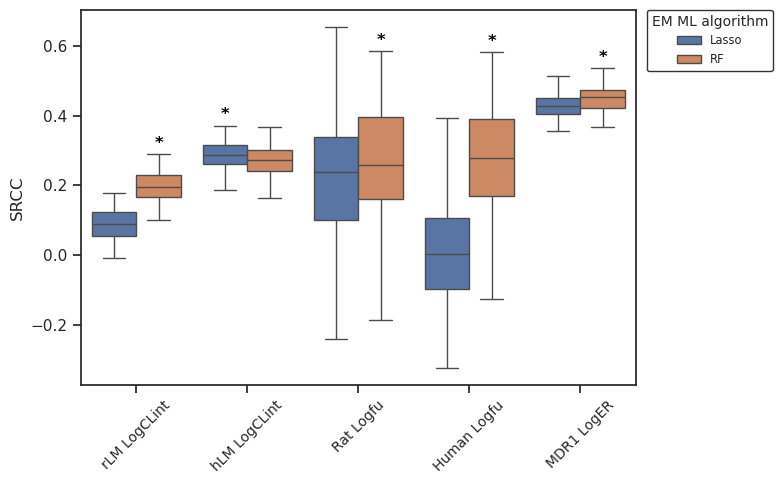

In [55]:
error_models_display_names = {'UniqueRandomForestRegressor[UQmetrics+predictions](l1)': 'RF',
                              'UniqueLASSO[UQmetrics+predictions](l1)': 'Lasso'}

plt.figure(figsize=(8, 5))
ax = sns.boxplot(data=boxplots_df, x="endpoint", y="eval_metric", hue="uq_method",
                 order=endpoints, hue_order=error_models_list, linewidth=1, fliersize=3, showfliers=False)
plt.ylabel('SRCC')
plt.xlabel('')
plt.xticks(ticks=ax.get_xticks(), labels=endpoint_names, fontsize=10, rotation=45)

# add '*' label to the best method for each endpoint
boxplot_width = 0.8
n_methods = len(error_models_list)
each_width = boxplot_width / n_methods
for endpoint in endpoints:
    for best_method in best_methods[endpoint]:
        # Get endpoint and method indexes and compute the x-coordinate
        endpoint_index = endpoints.index(endpoint)
        method_index = error_models_list.index(best_method)
        x_coord = endpoint_index + (method_index - (n_methods - 1) / 2) * each_width
        # Compute the y-coordinate
        values = boxplots_df['eval_metric'].loc[(boxplots_df.endpoint == endpoint) & (boxplots_df.uq_method == best_method)].values
        q1, q3 = np.percentile(values, [25, 75])
        iqr = q3 - q1
        upper_whisker = values[values <= q3 + 1.5 * iqr].max()
        y_coord = upper_whisker + 0.01
        # Add the '*' text label at the computed coordinates
        ax.text(x=x_coord, y=y_coord, s='*', ha='center', va='bottom', fontsize=12, color='black', weight='semibold')

handles, labels = ax.get_legend_handles_labels()
new_labels = [error_models_display_names[label] for label in labels]
# Anchor the legend's upper-left corner just outside the axes' right edge,
# so its position doesn't depend on the legend's width
plt.legend(handles, new_labels, loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0,
           fontsize='x-small', title='EM ML algorithm', title_fontsize='small',
           frameon=True, fancybox=True, facecolor='white', edgecolor='black')


plt.tight_layout()
plt.show()

## Figure 5

Compare the effect of the **amount of training data** used to fit the UNIQUE error model. The baseline (`UniqueRandomForestRegressor[UQmetrics+predictions](l1)`) is trained on Training + Calibration. The `em_predictions_*train` columns come from `inputdata_benchmarking_data.csv` (produced by `Building_Error_Models.ipynb`): 100% = Training only, and 75/50/25% = that fraction of Training plus the full Calibration set.

In [45]:
error_models_list = ['UniqueRandomForestRegressor[UQmetrics+predictions](l1)',
                     'em_predictions_100train', 'em_predictions_75train',
                     'em_predictions_50train', 'em_predictions_25train']

In [46]:
bs_results = {}
best_methods = {}

for endpoint, models_dict in endpoints_dict.items():
    print(f'\n### {endpoint} ###\n')

    for model_name, model_id in models_dict.items():
        print(f'\n### {model_name} ###\n')
        bs_results[model_name] = {}
        best_methods[model_name] = {}

        # Load UNIQUE input data
        input_data = pd.read_csv(f'unique_input_data/{model_name}_unique_input_data.csv', index_col=0).reset_index(drop=True)
        print(input_data.shape)
        # Load UNIQUE-computed uncertainty values (baseline EM)
        uq_metrics_data = pd.read_csv(f'unique_output/{model_id}/{model_id}_uq_metrics_values.csv')
        print(uq_metrics_data.shape)
        # Load benchmark predictions from Building_Error_Models.ipynb
        uq_metrics_data_benchmark = pd.read_csv(
            f'unique_output/{model_id}/error_models/UQmetrics_predictions/inputdata_benchmarking_data.csv')
        print(uq_metrics_data_benchmark.shape)

        # Aggregate
        bs_df = pd.concat([input_data[['Id', 'labels', 'predictions', 'which_set']],
                           uq_metrics_data[error_models_list[0]],
                           uq_metrics_data_benchmark[error_models_list[1:]]], axis=1)
        print(bs_df.shape)

        bs_df_test = bs_df.loc[bs_df.which_set == 'TEST'].reset_index(drop=True)
        print(bs_df_test.shape)

        # Bootstrap resampling
        replicas_dict = {"uq_values": [], "predictions": [], "labels": []}
        n_bootstrap = 100
        np.random.seed(seed)
        for _ in range(n_bootstrap):
            sample_indices = np.random.choice(len(bs_df_test), size=len(bs_df_test))
            replicas_dict["uq_values"].append(bs_df_test.iloc[sample_indices][error_models_list])
            replicas_dict["predictions"].append(bs_df_test.predictions[sample_indices])
            replicas_dict["labels"].append(bs_df_test.labels[sample_indices])

        for uq_method in error_models_list:
            spearman_values = []
            for n in range(n_bootstrap):
                uq_values = replicas_dict["uq_values"][n][uq_method]
                spearman = stats.spearmanr(np.abs(replicas_dict["predictions"][n] - replicas_dict["labels"][n]),
                                           uq_values)[0]
                spearman_values.append(spearman)
            bs_results[model_name][uq_method] = spearman_values

        # Pairwise Wilcoxon + BH correction
        comparisons = list(itertools.combinations(error_models_list, 2))
        wilcoxon_results = []
        for method1, method2 in comparisons:
            data1 = np.array(bs_results[model_name][method1])
            data2 = np.array(bs_results[model_name][method2])
            differences = data1 - data2
            if np.all(differences == 0):
                p_value = 1.0
            else:
                _, p_value = wilcoxon(differences)
            mean_diff = np.mean(data1) - np.mean(data2)
            wilcoxon_results.append((method1, method2, mean_diff, p_value))

        wilcoxon_df = pd.DataFrame(wilcoxon_results, columns=["group1", "group2", "meandiff", "p"])
        reject, p_values_corrected, _, _ = multipletests(wilcoxon_df["p"].values, alpha=0.05, method="fdr_bh")
        wilcoxon_df["p_adj"] = p_values_corrected
        wilcoxon_df["reject"] = reject

        method_scores = {method: 0 for method in error_models_list}
        for _, row in wilcoxon_df.iterrows():
            method1, method2, mean_diff, p_value, p_adj, reject = row
            if reject:
                if mean_diff > 0:
                    method_scores[method1] += 1
                elif mean_diff < 0:
                    method_scores[method2] += 1

        best_method = [method for method, score in method_scores.items() if score == max(method_scores.values())]

        wilcoxon_filtered = wilcoxon_df.loc[(wilcoxon_df['group1'].eq(best_method[0]) | wilcoxon_df['group2'].eq(best_method[0])), :]
        is_best_different = []
        for _, row in wilcoxon_filtered.iterrows():
            method1, method2, _, _, _, reject = row
            is_best_different.append({'method': method1 if best_method[0] != method1 else method2,
                                      'is_best_significant': reject})
        is_best_different_df = pd.DataFrame(is_best_different)

        best_methods[model_name] = [best_method[0]] + is_best_different_df['method'].loc[is_best_different_df.is_best_significant == False].tolist()


### clint ###


### rLM LogCLint ###

(3051, 7)
(3051, 9)
(3051, 14)
(3051, 9)
(609, 9)

### hLM LogCLint ###

(3084, 7)
(3084, 9)
(3084, 14)
(3084, 9)
(616, 9)

### ppb ###


### LogFu-Rat ###

(167, 7)
(167, 9)
(167, 14)
(167, 9)
(32, 9)

### LogFu-Human ###

(193, 7)
(193, 9)
(193, 14)
(193, 9)
(39, 9)

### mdr1 ###


### MDCK-MDR1_LogER ###

(2639, 7)
(2639, 9)
(2639, 14)
(2639, 9)
(527, 9)


In [48]:
boxplots_df = pd.DataFrame()
for endpoint, inner_dict in bs_results.items():
    for uq_method, spearman_values in inner_dict.items():
        tmp_df = pd.DataFrame({'endpoint': endpoint, 'uq_method': uq_method, 'eval_metric': spearman_values})
        boxplots_df = pd.concat([boxplots_df, tmp_df], ignore_index=True)

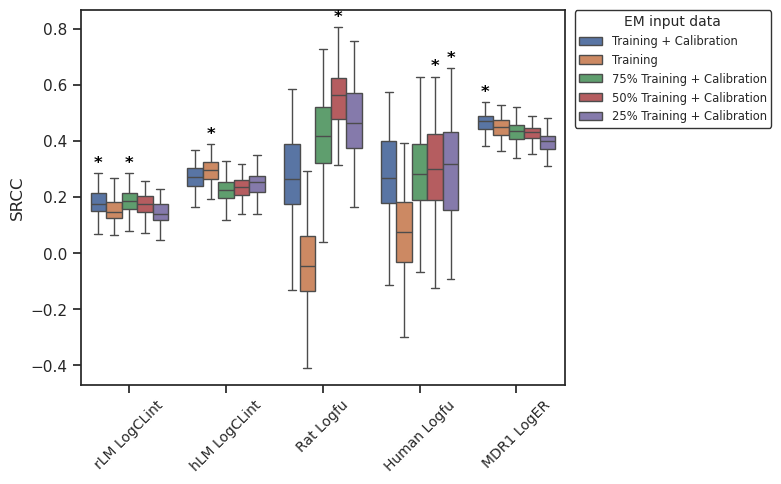

In [50]:
error_models_display_names = {'UniqueRandomForestRegressor[UQmetrics+predictions](l1)': 'Training + Calibration',
                              'em_predictions_100train': 'Training',
                              'em_predictions_75train': '75% Training + Calibration',
                              'em_predictions_50train': '50% Training + Calibration',
                              'em_predictions_25train': '25% Training + Calibration'}

plt.figure(figsize=(8, 5))
ax = sns.boxplot(data=boxplots_df, x="endpoint", y="eval_metric", hue="uq_method",
                 order=endpoints, hue_order=error_models_list, linewidth=1, fliersize=3, showfliers=False)
plt.ylabel('SRCC')
plt.xlabel('')
plt.xticks(ticks=ax.get_xticks(), labels=endpoint_names, fontsize=10, rotation=45)

# add '*' label to the best method for each endpoint
boxplot_width = 0.8
n_methods = len(error_models_list)
each_width = boxplot_width / n_methods
for endpoint in endpoints:
    for best_method in best_methods[endpoint]:
        # Get endpoint and method indexes and compute the x-coordinate
        endpoint_index = endpoints.index(endpoint)
        method_index = error_models_list.index(best_method)
        x_coord = endpoint_index + (method_index - (n_methods - 1) / 2) * each_width
        # Compute the y-coordinate
        values = boxplots_df['eval_metric'].loc[(boxplots_df.endpoint == endpoint) & (boxplots_df.uq_method == best_method)].values
        q1, q3 = np.percentile(values, [25, 75])
        iqr = q3 - q1
        upper_whisker = values[values <= q3 + 1.5 * iqr].max()
        y_coord = upper_whisker + 0.01
        # Add the '*' text label at the computed coordinates
        ax.text(x=x_coord, y=y_coord, s='*', ha='center', va='bottom', fontsize=12, color='black', weight='semibold')

handles, labels = ax.get_legend_handles_labels()
new_labels = [error_models_display_names[label] for label in labels]
# Anchor the legend's upper-left corner just outside the axes' right edge,
# so its position doesn't depend on the legend's width
plt.legend(handles, new_labels, loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0,
           fontsize='x-small', title='EM input data', title_fontsize='small',
           frameon=True, fancybox=True, facecolor='white', edgecolor='black')


plt.tight_layout()
plt.show()